# ScreenSense — Exploratory Data Analysis

## Core Analytical Question

Is daily screen time alone sufficient to describe digital wellbeing patterns, or do app category, engagement intensity, notification exposure, and usage timing provide additional behavioural context?

> Note: The dataset is synthetic and record-level. Findings represent associations and behavioural patterns within the dataset, not causal relationships or medical diagnoses.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/processed/screensense_clean.csv")

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (10000, 21)


,record_id,year,month,day_of_week,country,age_group,gender,app_category,app_name,subscription_type,daily_screen_time_minutes,session_duration_minutes,sessions_per_day,app_opens_per_day,notifications_received_per_day,notification_settings,primary_usage_time,sleep_disruption_from_phone,screen_time_concern,mental_health_impact,digital_wellbeing_feature_used
0,APP0000001,2024,11,Thursday,Turkey,45-54,Male,Social Media,Snapchat,Paid Yearly,76.4,41.0,9,12,26,Selected Only,Lunch (12-2pm),Moderate,Yes,Positive,Yes
1,APP0000002,2022,5,Friday,USA,25-34,Male,Shopping,Etsy,Freemium,82.2,19.3,6,9,25,Selected Only,Evening (6-10pm),Not Reported,Yes,Negative,Yes
2,APP0000003,2024,9,Sunday,USA,25-34,Male,Food Delivery,Deliveroo,Free,15.8,18.0,2,5,25,Selected Only,Evening (6-10pm),Not Reported,No,Negative,No
3,APP0000004,2023,7,Tuesday,Pakistan,25-34,Male,Entertainment/Streaming,Twitch,Freemium,62.4,92.6,5,8,19,All Notifications,Commute (9-11am),Moderate,Somewhat,Negative,Yes
4,APP0000005,2023,3,Tuesday,UAE,25-34,Male,Communication/Messaging,Viber,Freemium,89.5,34.2,1,6,25,Completely Off,Commute (9-11am),Moderate,Yes,Neutral,Yes


## 1. Baseline Analysis: Daily Screen Time Distribution

Before evaluating behavioural context, we first examine the distribution of daily screen time as the conventional measure of smartphone usage intensity.

count    10000.00
mean        85.50
std         70.97
min          5.70
25%         35.50
50%         63.40
75%        112.70
max        600.00
Name: daily_screen_time_minutes, dtype: float64


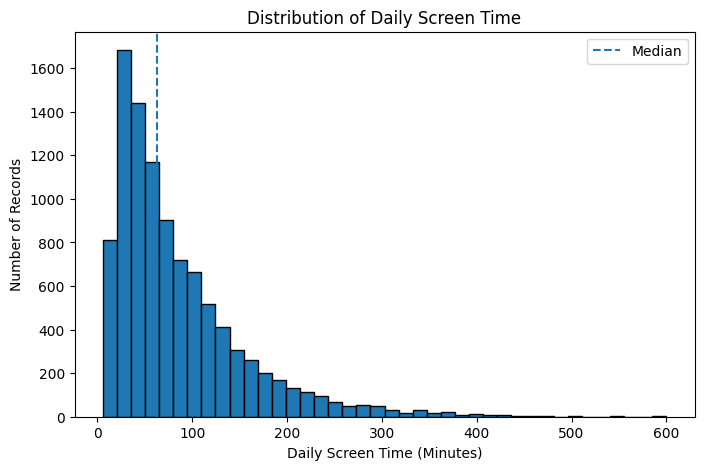

In [2]:
screen_time_stats = df["daily_screen_time_minutes"].describe()

print(screen_time_stats.round(2))

plt.figure(figsize=(8, 5))
plt.hist(df["daily_screen_time_minutes"], bins=40, edgecolor="black")

plt.axvline(
    df["daily_screen_time_minutes"].median(),
    linestyle="--",
    label="Median"
)

plt.xlabel("Daily Screen Time (Minutes)")
plt.ylabel("Number of Records")
plt.title("Distribution of Daily Screen Time")
plt.legend()

plt.show()

### Observation

Daily screen time is strongly right-skewed. Most usage records are concentrated at lower to moderate screen-time levels, while a smaller number of high-usage records form a long right tail. The mean screen time (85.5 minutes) is higher than the median (63.4 minutes), indicating that extreme high-usage records pull the average upward.

## 2. Does Screen Time Alone Reflect Digital Wellbeing?

If screen time is a sufficient indicator of problematic digital behaviour, records reporting greater screen-time concern should show clearly higher daily screen time.

In [3]:
concern_analysis = (
    df.groupby("screen_time_concern")["daily_screen_time_minutes"]
    .agg(["count", "mean", "median"])
    .round(2)
    .sort_values("mean", ascending=False)
)

display(concern_analysis)

,count,mean,median
screen_time_concern,,,
Somewhat,2726,86.83,63.25
Yes,3753,86.28,65.00
No,3521,83.64,62.10


### Observation

Average and median daily screen time are very similar across all screen-time concern groups. Records reporting concern do not show substantially higher screen time than records reporting no concern.

This suggests that screen time alone provides limited separation between self-reported concern levels and motivates examining broader behavioural context.

## 3. Screen Time Across App Categories

The analysis now examines whether screen-time intensity varies across different types of app usage.

In [4]:
category_screen_time = (
    df.groupby("app_category")["daily_screen_time_minutes"]
    .agg(["count", "mean", "median"])
    .round(2)
    .sort_values("mean", ascending=False)
)

display(category_screen_time)

,count,mean,median
app_category,,,
Social Media,1992,145.74,127.1
Entertainment/Streaming,1287,121.19,104.8
Gaming,1367,114.83,94.4
Communication/Messaging,616,76.89,69.3
Productivity,960,65.22,58.0
Education,820,52.83,47.0
News & Media,528,40.77,35.1
Health & Fitness,831,37.57,34.4
Shopping,721,34.31,30.4


### Observation

Daily screen time varies substantially across app categories. Social Media records show the highest average screen time (145.74 minutes), followed by Entertainment/Streaming and Gaming. In contrast, transactional categories such as Food Delivery and Finance/Banking show much lower average screen time.

This indicates that usage context differs considerably across app categories and supports analysing screen time alongside the type of digital activity.

In [5]:
engagement_corr = df[
    [
        "daily_screen_time_minutes",
        "session_duration_minutes",
        "sessions_per_day",
        "app_opens_per_day",
        "notifications_received_per_day"
    ]
].corr().round(2)

display(engagement_corr)

,daily_screen_time_minutes,session_duration_minutes,sessions_per_day,app_opens_per_day,notifications_received_per_day
daily_screen_time_minutes,1.00,0.27,-0.01,-0.02,0.00
session_duration_minutes,0.27,1.00,0.00,-0.01,0.02
sessions_per_day,-0.01,0.00,1.00,0.01,0.01
app_opens_per_day,-0.02,-0.01,0.01,1.00,0.01
notifications_received_per_day,0.00,0.02,0.01,0.01,1.00


### Observation

Daily screen time shows only a weak positive correlation with session duration (0.27) and almost no linear relationship with session frequency, app opens, or notifications received.

This suggests that usage duration and engagement frequency capture different behavioural dimensions. High screen time does not necessarily imply frequent app checking or greater notification exposure.

In [6]:
df["screen_time_band"] = pd.qcut(
    df["daily_screen_time_minutes"],
    q=4,
    labels=["Low", "Moderate", "High", "Very High"]
)

band_behaviour = (
    df.groupby("screen_time_band", observed=True)
    [
        [
            "sessions_per_day",
            "app_opens_per_day",
            "notifications_received_per_day",
            "session_duration_minutes"
        ]
    ]
    .mean()
    .round(2)
)

display(band_behaviour)

,sessions_per_day,app_opens_per_day,notifications_received_per_day,session_duration_minutes
screen_time_band,,,,
Low,6.08,8.04,25.07,21.96
Moderate,6.06,8.09,24.87,34.27
High,5.94,7.99,25.01,41.99
Very High,6.02,7.97,25.07,44.54


### Observation

Across screen-time quartiles, average session frequency, app opens, and notification volume remain relatively stable. However, average session duration increases substantially from 21.96 minutes in the Low screen-time band to 44.54 minutes in the Very High band.

Within this dataset, higher screen time appears more closely associated with longer usage sessions than with more frequent app checking or notification exposure.

## 5. Usage Timing and Sleep Disruption

Usage duration may not capture when smartphone engagement occurs. This section examines whether late-night usage records show different self-reported sleep disruption patterns.

In [7]:
sleep_timing = pd.crosstab(
    df["primary_usage_time"],
    df["sleep_disruption_from_phone"],
    normalize="index"
).mul(100).round(2)

display(sleep_timing)

sleep_disruption_from_phone,Mild,Moderate,Not Reported,Severe
primary_usage_time,,,,
Afternoon (2-6pm),34.15,24.45,27.33,14.08
Commute (9-11am),33.55,23.26,28.92,14.27
Evening (6-10pm),33.72,25.16,27.36,13.76
Late Night (10pm+),35.50,24.54,27.54,12.42
Lunch (12-2pm),36.07,24.59,27.69,11.64
Morning (6-9am),33.33,24.43,28.57,13.66


### Observation

Sleep disruption patterns remain broadly similar across primary usage-time groups. Late-night usage records do not show a higher proportion of severe sleep disruption than other usage periods.

Therefore, this dataset does not support the hypothesis that late-night primary usage is associated with greater self-reported sleep disruption.

In [8]:
category_concern = pd.crosstab(
    df["app_category"],
    df["screen_time_concern"],
    normalize="index"
).mul(100).round(2)

display(category_concern.sort_values("Yes", ascending=False))

screen_time_concern,No,Somewhat,Yes
app_category,,,
Social Media,33.13,27.81,39.06
Education,31.95,29.02,39.02
Health & Fitness,35.26,26.23,38.51
Entertainment/Streaming,34.50,27.12,38.38
Finance/Banking,37.86,24.45,37.69
Communication/Messaging,36.53,26.30,37.18
News & Media,37.31,25.76,36.93
Gaming,36.43,27.07,36.50
Shopping,36.62,27.18,36.20


### Observation

Screen-time concern varies modestly across app categories. Social Media shows one of the highest concern rates, but overall differences are limited.

In [9]:
wellbeing_usage = pd.crosstab(
    df["screen_time_concern"],
    df["digital_wellbeing_feature_used"],
    normalize="index"
).mul(100).round(2)

display(wellbeing_usage)

digital_wellbeing_feature_used,No,Yes
screen_time_concern,,
No,65.41,34.59
Somewhat,62.03,37.97
Yes,65.57,34.43


### Observation

Digital wellbeing feature adoption is similar across concern levels, suggesting that reported concern does not strongly translate into feature usage.